# 01. Exploratory Data Analysis

This notebook analyzes the project's three data sources (the Financial PhraseBank in two annotator-agreement configurations, the NIFTY headline/movement dataset, and the live yfinance feeds the pipeline calls) and ends in a set of conclusions that the pipeline notebook inherits. Nothing in the pipeline imports code from here; the handoff is the conclusions section.

All data sources are documented in [`docs/sources.md`](../docs/sources.md). The environment comes from `uv sync` at the repository root.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42  # deterministic results throughout

# Paths resolve from the repository root (the parent of notebooks/).
REPO_ROOT = Path.cwd().parent
assert (REPO_ROOT / "pyproject.toml").exists(), "run this notebook from notebooks/"
DATA_RAW = REPO_ROOT / "data" / "raw"
DATA_PROCESSED = REPO_ROOT / "data" / "processed"
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110

# The exact model configuration the pipeline notebook trains; every baseline
# below uses it so the numbers here and there are directly comparable.
def make_sentiment_pipeline():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True, ngram_range=(1, 2), min_df=2,
            sublinear_tf=True, max_features=10_000,
        )),
        ("classifier", LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE,
        )),
    ])

print("Setup complete.")

c:\Users\18587\Documents\Projects\University of San Diego\AAI-520 Final Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


## 2. PhraseBank configurations and the disagreement tail

The PhraseBank ships four configurations that differ in how many annotators had to agree on the label. `sentences_allagree` (unanimous annotators) is a strict subset of `sentences_50agree` (bare majority); subtracting one from the other yields the **disagreement tail**, the sentences whose labels annotators disputed.

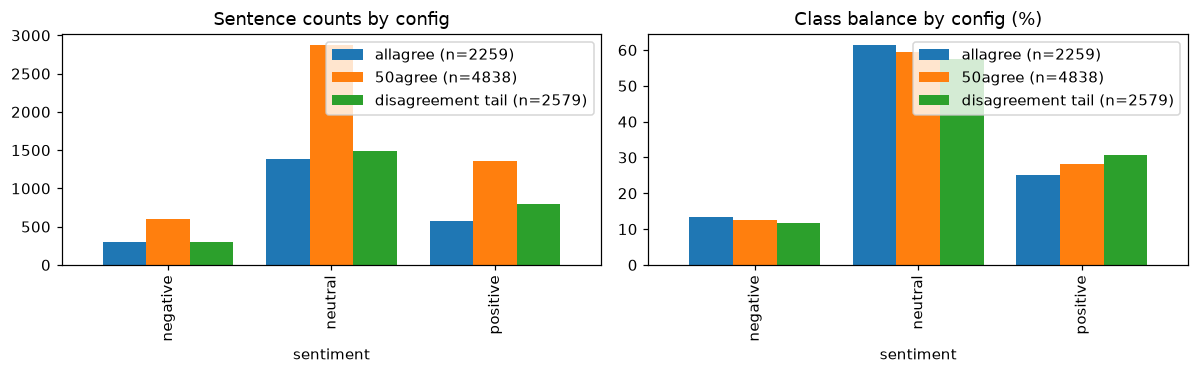

sentiment,negative,neutral,positive
allagree (n=2259),303,1386,570
50agree (n=4838),604,2872,1362
disagreement tail (n=2579),301,1486,792


In [2]:
def load_phrasebank(config):
    ds = load_dataset("takala/financial_phrasebank", config, trust_remote_code=True)["train"]
    frame = ds.to_pandas()
    frame["sentiment"] = frame["label"].map(dict(enumerate(ds.features["label"].names)))
    return frame.drop_duplicates(subset="sentence").reset_index(drop=True)

allagree = load_phrasebank("sentences_allagree")
fiftyagree = load_phrasebank("sentences_50agree")
residual = fiftyagree[~fiftyagree["sentence"].isin(set(allagree["sentence"]))].reset_index(drop=True)

order = ["negative", "neutral", "positive"]
balance = pd.DataFrame({
    f"{name} (n={len(frame)})": frame["sentiment"].value_counts().reindex(order)
    for name, frame in [("allagree", allagree), ("50agree", fiftyagree), ("disagreement tail", residual)]
})
balance_pct = balance / balance.sum(axis=0) * 100

allagree.to_csv(DATA_RAW / "phrasebank_allagree.csv", index=False)
residual.to_csv(DATA_RAW / "phrasebank_disagreement_tail.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
balance.plot.bar(ax=axes[0], width=0.8, title="Sentence counts by config")
axes[0].set_xlabel("sentiment")
balance_pct.plot.bar(ax=axes[1], width=0.8, title="Class balance by config (%)")
axes[1].set_xlabel("sentiment")
plt.tight_layout()
plt.show()

display(balance.T.round(0))

In [3]:
allagree["n_words"] = allagree["sentence"].str.split().str.len()
allagree["n_words"].groupby(allagree["sentiment"]).describe().round(1)

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,303.0,24.8,10.3,5.0,17.0,22.0,30.0,56.0
neutral,1386.0,20.9,9.6,2.0,14.0,19.0,26.0,81.0
positive,570.0,24.9,10.5,6.0,17.0,23.0,31.0,57.0


## 3. Within-config baselines

The model is fixed; only the training labels change. The accuracy gap between the two configs is therefore label noise, not model capacity.

In [4]:
def evaluate_within_config(frame, name):
    x_train, x_test, y_train, y_test = train_test_split(
        frame["sentence"], frame["sentiment"],
        test_size=0.20, stratify=frame["sentiment"], random_state=RANDOM_STATE,
    )
    model = make_sentiment_pipeline().fit(x_train, y_train)
    predictions = model.predict(x_test)
    report = classification_report(y_test, predictions, output_dict=True, zero_division=0)
    return {
        "config": name,
        "train n": len(x_train), "test n": len(x_test),
        "accuracy": report["accuracy"],
        "macro-F1": report["macro avg"]["f1-score"],
        **{f"{label} F1": report[label]["f1-score"] for label in order},
    }

within_config = pd.DataFrame([
    evaluate_within_config(allagree, "allagree (unanimous labels)"),
    evaluate_within_config(fiftyagree, "50agree (majority labels)"),
]).set_index("config")
within_config.round(3)

,train n,test n,accuracy,macro-F1,negative F1,neutral F1,positive F1
config,,,,,,,
allagree (unanimous labels),1807,452,0.894,0.862,0.825,0.940,0.821
50agree (majority labels),3870,968,0.749,0.713,0.675,0.809,0.654


## 4. Transfer to the disagreement tail

Train on every clean allagree sentence, then predict the 2,579 tail sentences the model has never seen and whose labels annotators disputed. This is the pre-deployment estimate of live-headline performance. Tail labels are bare-majority votes: errors here overstate model failure on genuinely clear sentences and understate it on genuinely ambiguous ones.

In [5]:
allagree_model = make_sentiment_pipeline().fit(allagree["sentence"], allagree["sentiment"])
tail_predictions = allagree_model.predict(residual["sentence"])

tail_report = classification_report(residual["sentiment"], tail_predictions, output_dict=True, zero_division=0)
transfer_summary = pd.Series({
    "tail sentences": len(residual),
    "accuracy": tail_report["accuracy"],
    "macro-F1": tail_report["macro avg"]["f1-score"],
    "negative F1": tail_report["negative"]["f1-score"],
    "neutral F1": tail_report["neutral"]["f1-score"],
    "positive F1": tail_report["positive"]["f1-score"],
})
display(transfer_summary.round(3))
print(classification_report(residual["sentiment"], tail_predictions, zero_division=0))

mismatches = residual.assign(predicted=tail_predictions)
mismatches = mismatches[mismatches["sentiment"] != mismatches["predicted"]]
print(f"\nExample disagreements ({len(mismatches)} of {len(residual)} misclassified):")
for _, row in mismatches.head(5).iterrows():
    print(f"  true [{row['sentiment']:>8}] predicted [{row['predicted']:>8}]  {row['sentence'][:80]}")

tail sentences    2579.000
accuracy             0.620
macro-F1             0.473
negative F1          0.295
neutral F1           0.739
positive F1          0.386
dtype: float64

              precision    recall  f1-score   support

    negative       0.52      0.21      0.30       301
     neutral       0.64      0.88      0.74      1486
    positive       0.56      0.29      0.39       792

    accuracy                           0.62      2579
   macro avg       0.57      0.46      0.47      2579
weighted avg       0.60      0.62      0.58      2579


Example disagreements (979 of 2579 misclassified):
  true [negative] predicted [ neutral]  The international electronic industry company Elcoteq has laid off tens of emplo
  true [positive] predicted [ neutral]  With the new production plant the company would increase its capacity to meet th
  true [positive] predicted [ neutral]  FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is aggressively pursuing its growth str
  true [positive] predicted [ neutral]  STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMENE Credit Suisse First Boston ( CFS
  true [positive] predicted [ neutral]  A purchase agreement for 7,200 tons of gaso

## 5. Class-weighting ablation

The corpus runs roughly 60% neutral / 28% positive / 12% negative. An unweighted classifier trades negative recall for accuracy; the ablation quantifies the trade for `class_weight=None` versus `class_weight="balanced"`.

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    allagree["sentence"], allagree["sentiment"],
    test_size=0.20, stratify=allagree["sentiment"], random_state=RANDOM_STATE,
)

ablation_rows = []
for weighting in [None, "balanced"]:
    steps = make_sentiment_pipeline().steps
    steps[1] = ("classifier", LogisticRegression(
        max_iter=1000, class_weight=weighting, random_state=RANDOM_STATE,
    ))
    model = Pipeline(steps).fit(x_train, y_train)
    report = classification_report(y_test, model.predict(x_test), output_dict=True, zero_division=0)
    ablation_rows.append({
        "class_weight": weighting or "None",
        "accuracy": report["accuracy"],
        "macro-F1": report["macro avg"]["f1-score"],
        **{f"{label} recall": report[label]["recall"] for label in order},
    })

ablation = pd.DataFrame(ablation_rows).set_index("class_weight")
ablation.round(3)

,accuracy,macro-F1,negative recall,neutral recall,positive recall
class_weight,,,,,
None,0.881,0.826,0.656,0.982,0.754
balanced,0.894,0.862,0.852,0.931,0.825


## 6. Top-weighted n-grams by class

The top-weighted n-grams per class, as a check that the model learned financial semantics rather than publisher-specific phrasing or template artifacts.

In [7]:
vectorizer = allagree_model.named_steps["tfidf"]
classifier = allagree_model.named_steps["classifier"]
features = np.array(vectorizer.get_feature_names_out())

top_terms = pd.DataFrame({
    label: features[classifier.coef_[i].argsort()[::-1][:10]]
    for i, label in enumerate(classifier.classes_)
})
top_terms.index = [f"rank {i + 1}" for i in range(10)]
top_terms

,negative,neutral,positive
rank 1,down,is,rose
rank 2,decreased,and,increased
rank 3,fell,be,up
rank 4,down from,the,increase
rank 5,decreased to,will,grew
rank 6,dropped,will be,up from
rank 7,lower,approximately,rose to
rank 8,decreased by,not,to
rank 9,declined,of the,year
rank 10,fall,business,from


## 7. NIFTY label semantics

NIFTY's labels are the S&P 500 ETF's next-day direction (`Rise` / `Fall` / `Neutral`, where Neutral bounds the change at ±0.5%), not sentence-level sentiment. Each row carries one day's headline block, the day's market-feature table in `context`, ready-made LLM prompt pairs in `conversations`, and the realized `pct_change`. NIFTY is therefore **outcome data**: suitable for testing whether aggregated sentiment aligns with labeled movement, not as a sentiment gold standard.

,rows,first date,last date
split,,,
test,317,2019-02-13,2020-09-21
train,1477,2010-01-06,2017-06-27
valid,317,2017-06-28,2019-02-12


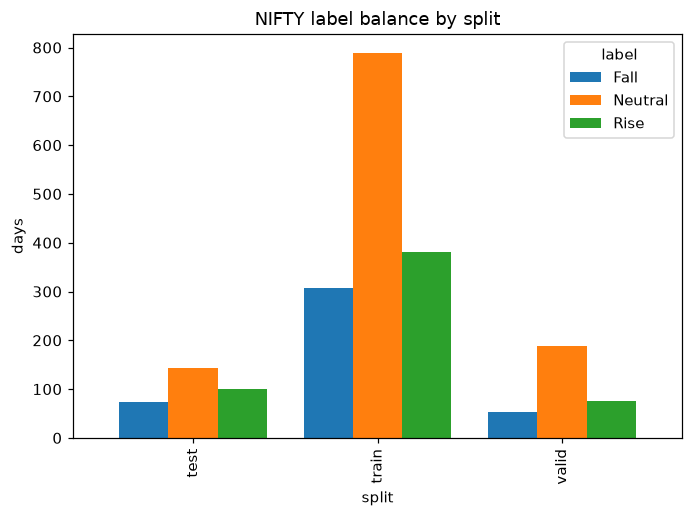

label,Fall,Neutral,Rise
split,,,
test,73,143,101
train,307,788,382
valid,53,189,75


Headlines per day: {'count': 2111.0, 'mean': 207.0, 'std': 360.1, 'min': 7.0, '25%': 47.0, '50%': 65.0, '75%': 93.0, 'max': 1627.0}

Realized pct_change by label:


,count,mean,min,max
label,,,,
Fall,433.0,-0.0134,-0.0957,-0.0050
Neutral,1120.0,0.0003,-0.0050,0.0050
Rise,558.0,0.0117,0.0050,0.0906


Neutral rows inside the ±0.5% band: 99.3%

Sample headlines (one day):
  • China Officials Likely Knew of Bad Milk
  • Sony's CEO on Strategy in 3-D Technology
  • Copper Settles at 16-Month High
  • Gold Ends Near 3-Week High
  • Kraft Gets Antitrust Clearance


In [8]:
nifty = load_dataset("raeidsaqur/NIFTY", trust_remote_code=True)
nifty_rows = []
for split in ["train", "valid", "test"]:
    frame = nifty[split].to_pandas()
    frame["split"] = split
    nifty_rows.append(frame)
nifty_all = pd.concat(nifty_rows, ignore_index=True)
nifty_all["n_headlines"] = nifty_all["news"].str.count("\n") + 1

profile = pd.DataFrame({
    "rows": nifty_all.groupby("split").size(),
    "first date": nifty_all.groupby("split")["date"].min(),
    "last date": nifty_all.groupby("split")["date"].max(),
})
display(profile)

label_balance = nifty_all.groupby(["split", "label"]).size().unstack(fill_value=0)
label_balance.plot.bar(title="NIFTY label balance by split", width=0.8)
plt.xlabel("split"); plt.ylabel("days"); plt.tight_layout(); plt.show()
display(label_balance)

print("Headlines per day:", nifty_all["n_headlines"].describe().round(1).to_dict())
print("\nRealized pct_change by label:")
display(nifty_all.groupby("label")["pct_change"].describe().round(4)[["count", "mean", "min", "max"]])
neutral_band = (nifty_all.loc[nifty_all["label"] == "Neutral", "pct_change"].abs() < 0.005).mean()
print(f"Neutral rows inside the ±0.5% band: {neutral_band:.1%}")
print("\nSample headlines (one day):")
for headline in nifty_all.iloc[0]["news"].split("\n")[:5]:
    print("  •", headline)

## 8. The live news corpus from `yf.Search`

The pipeline's news agent classifies what Yahoo Finance actually serves. Two measured properties: the `summary` field comes back empty (classification is title-only in practice), and headline selection drifts toward adjacent companies. The relevance filter addresses the drift; its company terms resolve at runtime from `yf.Ticker(t).info`, and when resolution fails the filter widens.

In [9]:
import re

import yfinance as yf

SUFFIXES = r"(inc|corp|corporation|ltd|plc|co|company|holdings|group|ag|se|nv|sa)\.?$"

def resolve_filter_terms(info):
    """Derive news-filter terms from yfinance ticker info."""
    terms = set()
    for name in {info.get("shortName"), info.get("longName")} - {None, ""}:
        base = re.sub(r"[^\w\s]", " ", str(name).lower())
        base = re.sub(SUFFIXES, "", base.strip()).strip()
        if base and len(base.split()[0]) > 1:
            terms.add(base.split()[0])
    if info.get("symbol"):
        terms.add(re.escape(info["symbol"].lower()))
    return sorted(terms)

search = yf.Search("AAPL", news_count=15)
news = pd.DataFrame([
    {"title": item.get("title") or "", "publisher": item.get("publisher") or "",
     "summary_empty": not (item.get("summary") or item.get("description") or "").strip()}
    for item in (search.news or [])
])

print(f"Articles retrieved: {len(news)}")
print(f"Empty summary rate: {news['summary_empty'].mean():.0%}")
print(f"Title length (words): {news['title'].str.split().str.len().describe().round(1).to_dict()}")
print("\nPublisher mix:")
display(news["publisher"].value_counts().to_frame("articles"))

apple_terms = resolve_filter_terms(yf.Ticker("AAPL").info or {})
print(f"Runtime-resolved filter terms for AAPL: {apple_terms}")

pattern = "|".join(apple_terms)
news["relevant"] = news["title"].str.contains(pattern, case=False, regex=True)
print(f"\nRelevance pass rate: {news['relevant'].mean():.0%} ({news['relevant'].sum()} of {len(news)})")
print("\nDropped as off-topic:")
for title in news.loc[~news["relevant"], "title"]:
    print("  •", title[:90])

Articles retrieved: 13
Empty summary rate: 100%
Title length (words): {'count': 13.0, 'mean': 11.8, 'std': 3.8, 'min': 8.0, '25%': 9.0, '50%': 11.0, '75%': 15.0, 'max': 20.0}

Publisher mix:


,articles
publisher,
GuruFocus.com,3
TIKR,3
Yahoo Finance,2
Investor's Business Daily,1
Stocktwits,1
Motley Fool,1
MoneyLion,1
Simply Wall St.,1


Runtime-resolved filter terms for AAPL: ['aapl', 'apple']

Relevance pass rate: 54% (7 of 13)

Dropped as off-topic:
  • The tech industry wants you to run AI models at home, but it's not for everyone
  • Microsoft debuts Nvidia-powered Surface Laptop Ultra, as it aims for AI market
  • Micron’s 107% Upside Scenario Depends on Precisely 1 Thing
  • Broadcom vs. Qualcomm: Rapid Growth vs. Flat Revenue
  • Want to “Get Defensive” in 2026? Buy These 3 Stocks
  • Nvidia, Palantir and Microsoft Among Dan Ives' Top 5 Tech Picks


## 9. Market return profile

Daily returns are heavy-tailed and volatility clusters; the pipeline's three-way moving-average trend label is a coarse summary, not a forecast. The market-evaluation section scores signals against realized forward movement with a majority-class baseline alongside (TODO). The closes here are unadjusted (`auto_adjust=False`); the pipeline's Market Analysis Agent uses adjusted closes (`auto_adjust=True`), so its prices include dividend and split adjustments.

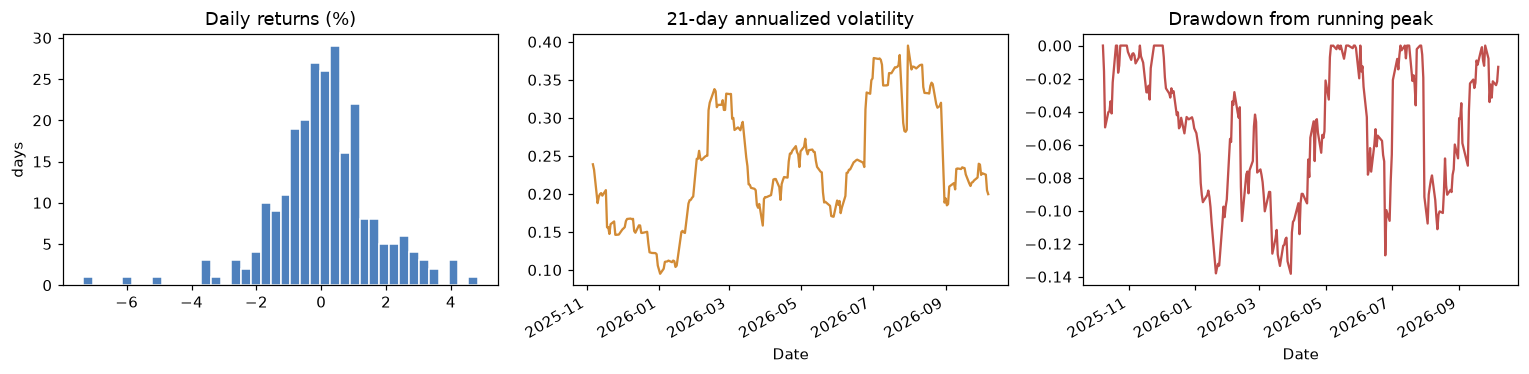

trading days               251.00
period return %             30.46
annualized volatility %     24.75
skew                        -0.49
excess kurtosis              3.17
max drawdown %             -13.82
worst day %                 -7.35
best day %                   4.84
dtype: float64

In [10]:
ticker = yf.Ticker("AAPL")
prices = ticker.history(period="1y", interval="1d", auto_adjust=False)
returns = prices["Close"].pct_change().dropna()

rolling_vol = returns.rolling(21).std() * np.sqrt(252)
drawdown = prices["Close"] / prices["Close"].cummax() - 1

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].hist(returns * 100, bins=40, color="#4f81bd", edgecolor="white")
axes[0].set_title("Daily returns (%)"); axes[0].set_ylabel("days")
rolling_vol.plot(ax=axes[1], color="#d28b36", title="21-day annualized volatility")
drawdown.plot(ax=axes[2], color="#c0504d", title="Drawdown from running peak")
plt.tight_layout(); plt.show()

market_stats = pd.Series({
    "trading days": len(prices),
    "period return %": (prices['Close'].iloc[-1] / prices['Close'].iloc[0] - 1) * 100,
    "annualized volatility %": returns.std() * np.sqrt(252) * 100,
    "skew": returns.skew(),
    "excess kurtosis": returns.kurt(),
    "max drawdown %": drawdown.min() * 100,
    "worst day %": returns.min() * 100,
    "best day %": returns.max() * 100,
})
returns.rename("daily_return").to_frame().assign(
    rolling_vol_annualized=rolling_vol, drawdown=drawdown
).to_csv(DATA_PROCESSED / "aapl_1y_return_profile.csv")

market_stats.round(2)

## 10. Conclusions for the pipeline

What the pipeline notebook inherits from the evidence above. The headline numbers are in the summary cell that follows.

1. **Train on `allagree`, report macro-F1.** Unanimous labels for training quality; macro-F1 as the primary metric because the corpus is ~60/28/12 imbalanced and accuracy flatters the neutral majority.
2. **State the disagreement-tail transfer score wherever the model's live performance is discussed.** The within-config score describes clean text; the tail score is the expectation on real headlines.
3. **Keep `class_weight="balanced"`.** The ablation quantifies what it buys in negative recall for what it costs in accuracy.
4. **Calibrate confidence in the pipeline notebook.** Confidence feeds the brief's caution rules; its bands should trace to the evidence here, not to intuition.
5. **NIFTY is outcome data.** Its labels are next-day SPY movement (Neutral = ±0.5%), so the market-evaluation section tests signal-against-outcome with a majority-class baseline, on chronological splits (TODO).
6. **Live news is title-only and off-topic drift is real.** Classify titles, keep the relevance filter, and resolve company terms at runtime from ticker info, with graceful widening when resolution fails.
7. **The trend label is coarse.** Returns are skewed, fat-tailed, and volatility-clustered; evaluation reports effect sizes against baselines, not bare direction counts (TODO).

In [11]:
summary = pd.DataFrame({
    "PhraseBank allagree sentences": [len(allagree)],
    "negative/neutral/positive": ["/".join(str(balance.loc[l, balance.columns[0]]) for l in order)],
    "PhraseBank 50agree sentences": [len(fiftyagree)],
    "disagreement-tail sentences": [len(residual)],
    "within-config accuracy (allagree / 50agree)": " / ".join(f"{v:.3f}" for v in within_config["accuracy"]),
    "within-config macro-F1 (allagree / 50agree)": " / ".join(f"{v:.3f}" for v in within_config["macro-F1"]),
    "tail transfer accuracy": [f"{transfer_summary['accuracy']:.3f}"],
    "tail transfer macro-F1": [f"{transfer_summary['macro-F1']:.3f}"],
    "negative recall, unweighted -> balanced": " -> ".join(f"{v:.2f}" for v in ablation["negative recall"]),
    "NIFTY days (train/valid/test)": "/".join(str(int((nifty_all['split'] == s).sum())) for s in ["train", "valid", "test"]),
    "NIFTY label majority share": [f"{(nifty_all['label'].value_counts(normalize=True).iloc[0]):.0%} "
                                    + nifty_all['label'].value_counts().index[0]],
    "live news empty-summary rate": [f"{news['summary_empty'].mean():.0%}"],
    "live news relevance pass rate": [f"{news['relevant'].mean():.0%}"],
    "AAPL annualized volatility %": [f"{market_stats['annualized volatility %']:.1f}"],
    "AAPL max drawdown %": [f"{market_stats['max drawdown %']:.1f}"],
}, index=["value"]).T
summary.index.name = "quantity"
summary

,value
quantity,
PhraseBank allagree sentences,2259
negative/neutral/positive,303/1386/570
PhraseBank 50agree sentences,4838
disagreement-tail sentences,2579
within-config accuracy (allagree / 50agree),0.894 / 0.749
within-config macro-F1 (allagree / 50agree),0.862 / 0.713
tail transfer accuracy,0.620
tail transfer macro-F1,0.473
"negative recall, unweighted -> balanced",0.66 -> 0.85
